In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv') #since the dataset is in a separate folder.

print(f'Training set : {train_df.shape[0]} rows, {train_df.shape[1]} columns')
print(f'Test set     : {test_df.shape[0]} rows, {test_df.shape[1]} columns')
train_df.head()

Training set : 1460 rows, 81 columns
Test set     : 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Basic statistics for the key features
features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
            'BedroomAbvGr', 'FullBath', 'HalfBath', 'BsmtFullBath',
            'TotRmsAbvGrd', 'SalePrice']

train_df[features].describe().round(2)

,GrLivArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,BedroomAbvGr,FullBath,HalfBath,BsmtFullBath,TotRmsAbvGrd,SalePrice
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00,1460.0
mean,1515.46,1057.43,1162.63,346.99,2.87,1.57,0.38,0.43,6.52,180921.2
std,525.48,438.71,386.59,436.53,0.82,0.55,0.50,0.52,1.63,79442.5
min,334.00,0.00,334.00,0.00,0.00,0.00,0.00,0.00,2.00,34900.0
25%,1129.50,795.75,882.00,0.00,2.00,1.00,0.00,0.00,5.00,129975.0
50%,1464.00,991.50,1087.00,0.00,3.00,2.00,0.00,0.00,6.00,163000.0
75%,1776.75,1298.25,1391.25,728.00,3.00,2.00,1.00,1.00,7.00,214000.0
max,5642.00,6110.00,4692.00,2065.00,8.00,3.00,2.00,3.00,14.00,755000.0


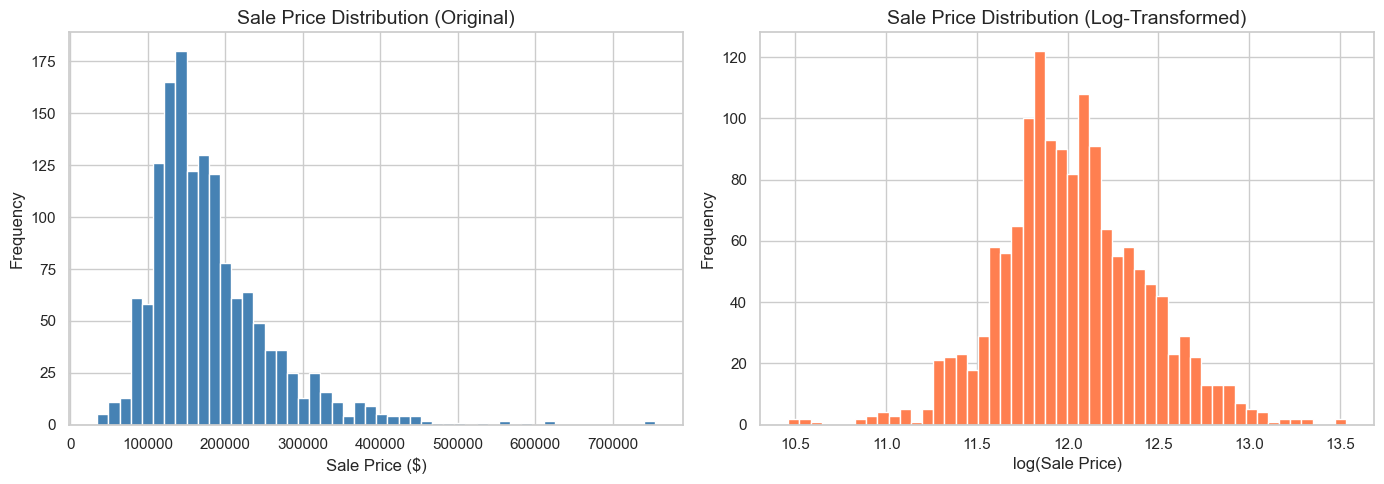

Skewness (original)        : 1.8829
Skewness (log-transformed) : 0.1213


In [5]:
# Distribution of Sale Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price Distribution (Original)', fontsize=14)
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(train_df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Sale Price Distribution (Log-Transformed)', fontsize=14)
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (original)        : {train_df['SalePrice'].skew():.4f}")
print(f"Skewness (log-transformed) : {np.log1p(train_df['SalePrice']).skew():.4f}")

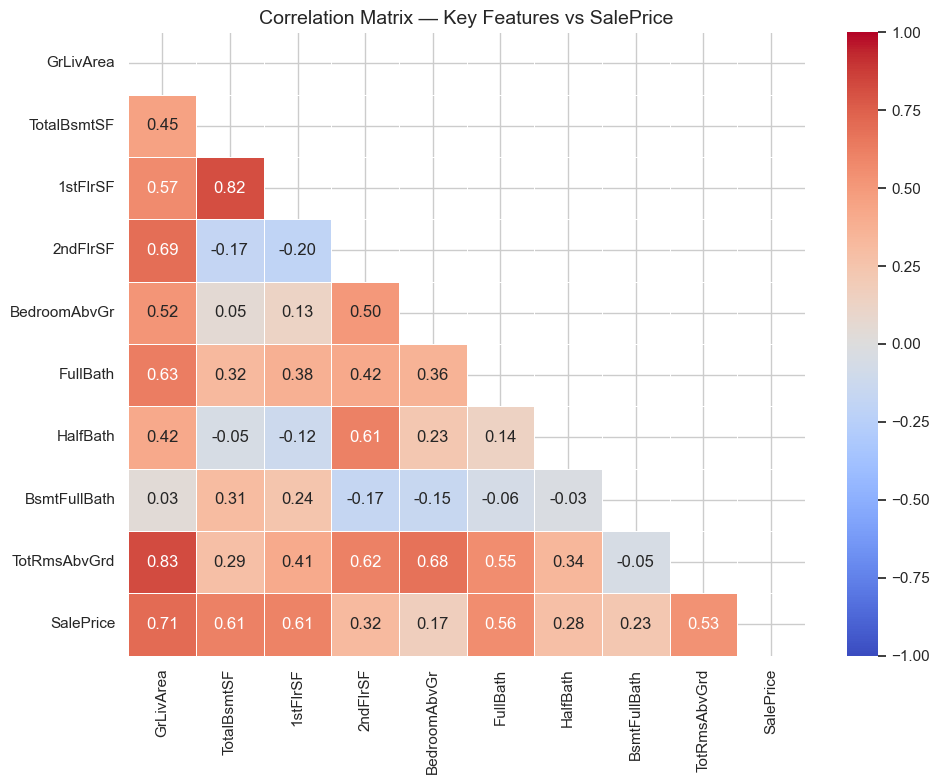

In [6]:
# Correlation heatmap of key features vs SalePrice
corr = train_df[features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Key Features vs SalePrice', fontsize=14)
plt.tight_layout()
plt.show()

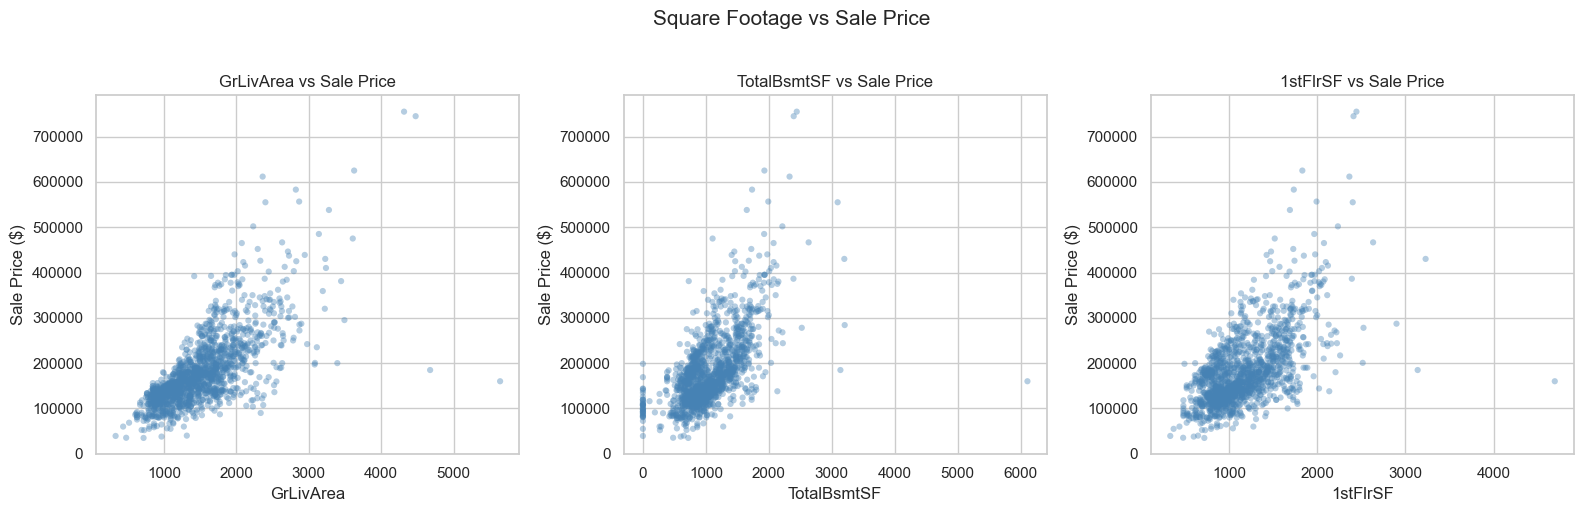

In [7]:
# Scatter plots: key square footage features vs SalePrice
sq_ft_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, sq_ft_features):
    ax.scatter(train_df[feat], train_df['SalePrice'],
               alpha=0.4, color='steelblue', edgecolors='none', s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel('Sale Price ($)')
    ax.set_title(f'{feat} vs Sale Price')

plt.suptitle('Square Footage vs Sale Price', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

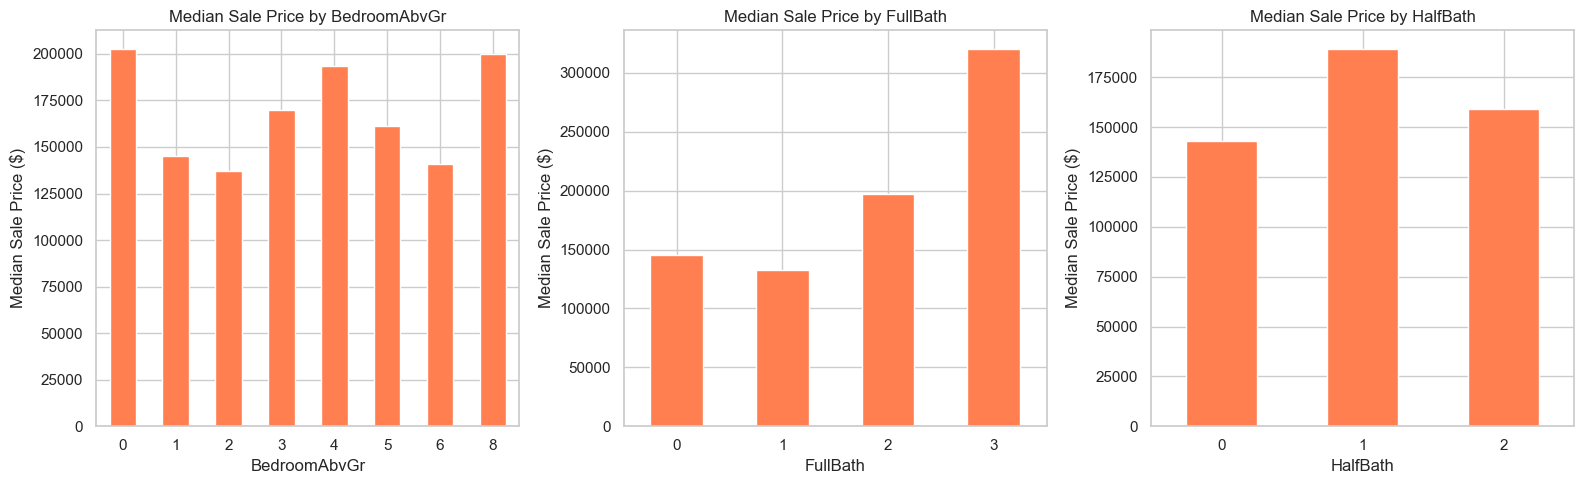

In [8]:
# Bedroom & Bathroom distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['BedroomAbvGr', 'FullBath', 'HalfBath']):
    train_df.groupby(feat)['SalePrice'].median().plot(kind='bar', ax=ax,
                                                       color='coral', edgecolor='white')
    ax.set_title(f'Median Sale Price by {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Median Sale Price ($)')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Select features for the model
FEATURES = [
    'GrLivArea',     # Above-grade living area sq ft
    'TotalBsmtSF',   # Total basement sq ft
    '1stFlrSF',      # First floor sq ft
    '2ndFlrSF',      # Second floor sq ft
    'BedroomAbvGr',  # Bedrooms above grade
    'FullBath',      # Full bathrooms above grade
    'HalfBath',      # Half bathrooms above grade
    'BsmtFullBath',  # Basement full bathrooms
    'TotRmsAbvGrd',  # Total rooms above grade
]
TARGET = 'SalePrice'

# Check for missing values in selected features
missing = train_df[FEATURES + [TARGET]].isnull().sum()
print('Missing values in selected features:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — all clean!')

Missing values in selected features:
None — all clean!


In [10]:
# Fill missing values with median (safe default for numeric features)
df = train_df[FEATURES + [TARGET]].copy()
df[FEATURES] = df[FEATURES].fillna(df[FEATURES].median())

# Feature Engineering: derived features
df['TotalSqFt']   = df['GrLivArea'] + df['TotalBsmtSF']       # Total living sq ft
df['TotalBaths']  = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath']  # Weighted bathrooms

FEATURES_ENG = FEATURES + ['TotalSqFt', 'TotalBaths']

# Log-transform the target to handle right skew
df['LogSalePrice'] = np.log1p(df[TARGET])

print('Engineered features added: TotalSqFt, TotalBaths')
print(f'Final feature count: {len(FEATURES_ENG)}')
df[FEATURES_ENG + ['LogSalePrice']].head()

Engineered features added: TotalSqFt, TotalBaths
Final feature count: 11


,GrLivArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,BedroomAbvGr,FullBath,HalfBath,BsmtFullBath,TotRmsAbvGrd,TotalSqFt,TotalBaths,LogSalePrice
0,1710,856,856,854,3,2,1,1,8,2566,3.5,12.247699
1,1262,1262,1262,0,3,2,0,0,6,2524,2.0,12.109016
2,1786,920,920,866,3,2,1,1,6,2706,3.5,12.317171
3,1717,756,961,756,3,1,0,1,7,2473,2.0,11.849405
4,2198,1145,1145,1053,4,2,1,1,9,3343,3.5,12.429220


In [11]:
X = df[FEATURES_ENG]
y = df['LogSalePrice']   # Predicting log(SalePrice); we'll inverse-transform for evaluation

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f'Training samples   : {X_train.shape[0]}')
print(f'Validation samples : {X_val.shape[0]}')

Training samples   : 1168
Validation samples : 292


In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Model trained!')
print(f'Intercept : {model.intercept_:.4f}')
print()

coef_df = pd.DataFrame({
    'Feature': FEATURES_ENG,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print('Feature Coefficients (standardised):')
print(coef_df.to_string(index=False))

Model trained!
Intercept : 12.0307

Feature Coefficients (standardised):
     Feature  Coefficient
    1stFlrSF     0.138813
    2ndFlrSF     0.125205
 TotalBsmtSF     0.097611
  TotalBaths     0.068225
    FullBath     0.067105
    HalfBath     0.053688
TotRmsAbvGrd     0.028395
   TotalSqFt     0.018296
BsmtFullBath     0.006939
   GrLivArea    -0.053304
BedroomAbvGr    -0.054197


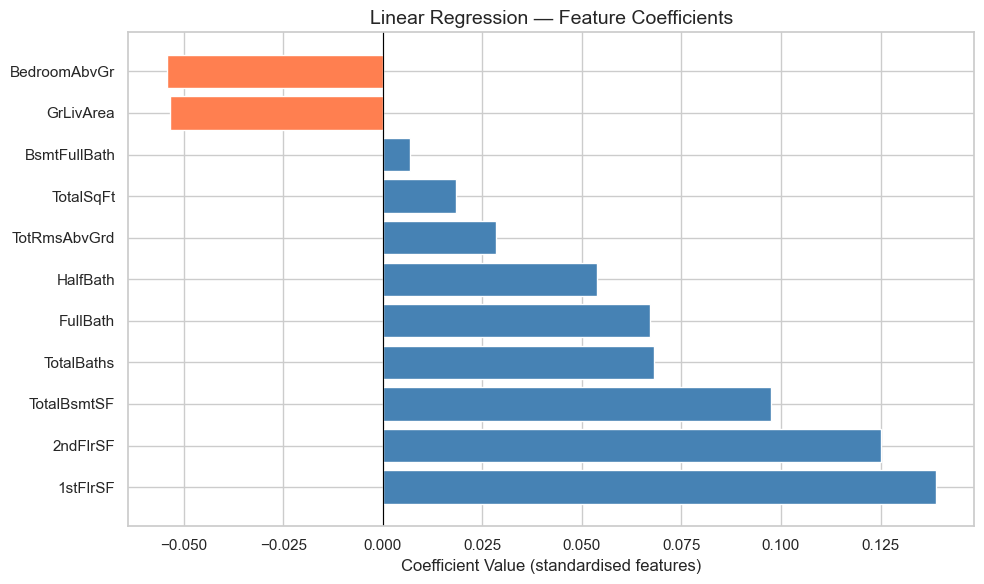

In [13]:
# Visualise feature coefficients
plt.figure(figsize=(10, 6))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression — Feature Coefficients', fontsize=14)
plt.xlabel('Coefficient Value (standardised features)')
plt.tight_layout()
plt.show()

In [14]:
# Predict on validation set (in log space, then inverse-transform)
y_pred_log = model.predict(X_val_scaled)
y_pred     = np.expm1(y_pred_log)   # Inverse of log1p
y_actual   = np.expm1(y_val)

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)

print('=' * 40)
print('       VALIDATION SET METRICS')
print('=' * 40)
print(f'  MAE  (Mean Absolute Error) : ${mae:,.0f}')
print(f'  RMSE (Root Mean Sq Error)  : ${rmse:,.0f}')
print(f'  R²   (R-Squared Score)     : {r2:.4f}')
print('=' * 40)

       VALIDATION SET METRICS
  MAE  (Mean Absolute Error) : $28,064
  RMSE (Root Mean Sq Error)  : $41,142
  R²   (R-Squared Score)     : 0.7793


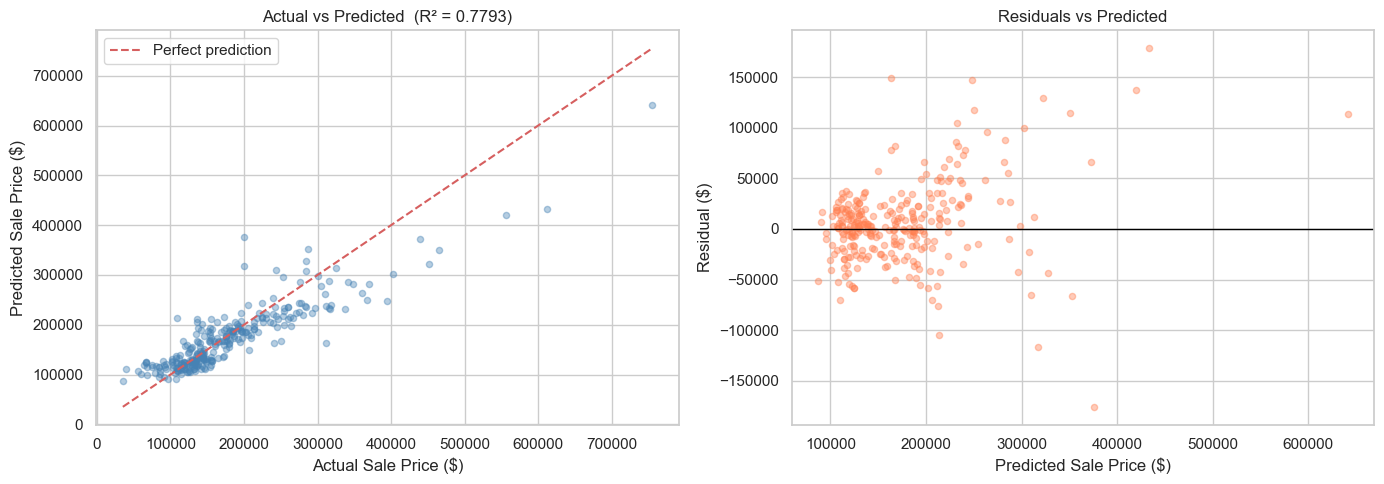

In [15]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_actual, y_pred, alpha=0.4, color='steelblue', s=20)
lims = [y_actual.min(), y_actual.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Sale Price ($)')
axes[0].set_ylabel('Predicted Sale Price ($)')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.4f})')
axes[0].legend()

# Residuals plot
residuals = y_actual - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted Sale Price ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

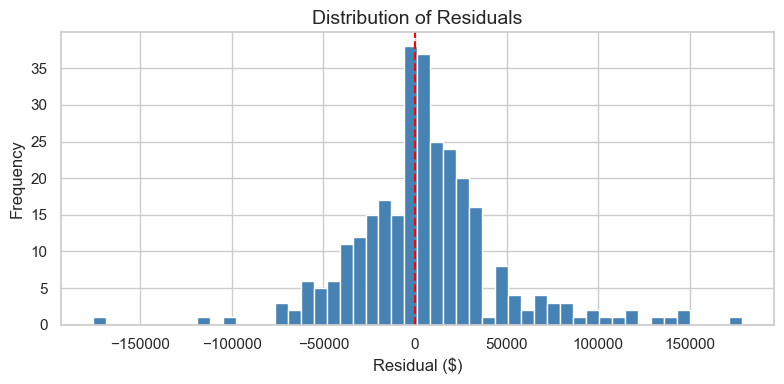

Mean residual  : $5,795   (should be near 0)
Std  residual  : $40,802


In [16]:
# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Mean residual  : ${residuals.mean():,.0f}   (should be near 0)')
print(f'Std  residual  : ${residuals.std():,.0f}')

In [17]:
# Prepare test data the same way
test = test_df[FEATURES].copy()
test = test.fillna(test.median())
test['TotalSqFt']  = test['GrLivArea'] + test['TotalBsmtSF']
test['TotalBaths'] = test['FullBath'] + 0.5 * test['HalfBath'] + test['BsmtFullBath']

X_test_scaled = scaler.transform(test[FEATURES_ENG])

# Predict
test_pred_log = model.predict(X_test_scaled)
test_pred     = np.expm1(test_pred_log)

# Save submission
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_pred
})
submission.to_csv('submission_linear_regression.csv', index=False)

print('Submission saved: submission_linear_regression.csv')
submission.head(10)

Submission saved: submission_linear_regression.csv


,Id,SalePrice
0,1461,114693.349551
1,1462,159701.686756
2,1463,184353.165474
3,1464,186534.886613
4,1465,173492.647209
5,1466,178977.662605
6,1467,172950.665543
7,1468,173552.987725
8,1469,184830.932666
9,1470,124067.837255


In [ ]:
#Save the model artifacts
import joblib
import os

# Create model directory if it doesn't exist
os.makedirs('model', exist_ok=True)

# Save the trained model and scaler
joblib.dump(model, 'model/model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')

# Save the feature list too — important for predict.py and app.py
joblib.dump(FEATURES_ENG, 'model/features.pkl')

print('model.pkl saved')
print(' scaler.pkl saved')
print(' features.pkl saved')

✅ model.pkl saved
✅ scaler.pkl saved
✅ features.pkl saved


In [ ]:
#Sanity check (quick test that the saved model works)
# Reload from disk and test a sample prediction
loaded_model  = joblib.load('model/model.pkl')
loaded_scaler = joblib.load('model/scaler.pkl')
loaded_feats  = joblib.load('model/features.pkl')

# Sample house: 1500 sqft, 3 bed, 2 full bath
sample = pd.DataFrame([{
    'GrLivArea'   : 1500,
    'TotalBsmtSF' : 800,
    '1stFlrSF'    : 800,
    '2ndFlrSF'    : 700,
    'BedroomAbvGr': 3,
    'FullBath'    : 2,
    'HalfBath'    : 0,
    'BsmtFullBath': 0,
    'TotRmsAbvGrd': 7,
    'TotalSqFt'   : 1500 + 800,
    'TotalBaths'  : 2 + 0.5*0 + 0
}])

pred = np.expm1(loaded_model.predict(loaded_scaler.transform(sample[loaded_feats])))[0]
print(f' The Sample prediction: ${pred:,.0f}')